In [1]:
!pip install -q torch

In [2]:
!pip install -q torchvision

In [3]:
!pip install -q torchsummary

In [4]:
!pip install -q -U watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.2 MB/s eta 0:00:00


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary

In [6]:
%reload_ext watermark
%watermark -a "Rafael Reis Santana" --iversions

Author: Rafael Reis Santana

PIL         : 11.3.0
matplotlib  : 3.10.0
numpy       : 2.0.2
torch       : 2.10.0+cu128
torchsummary: 1.5.1
torchvision : 0.25.0+cu128



In [7]:
# Bloco para seleção de dispositivo (CUDA, MPS ou CPU)

if torch.cuda.is_available():
    # Prioridade 1: GPU NVIDIA (CUDA)
    device = torch.device("cuda")
    print("Dispositivo selecionado: GPU NVIDIA (CUDA)")

elif torch.backends.mps.is_available():
    # Prioridade 2: GPU Apple (MPS)
    device = torch.device("mps")
    print("Dispositivo selecionado: GPU Apple (MPS)")

else:
    # Fallback: CPU
    device = torch.device("cpu")
    print("Dispositivo selecionado: CPU")

print(f'Usando dispositivo: {device}')

Dispositivo selecionado: GPU NVIDIA (CUDA)
Usando dispositivo: cuda


## Definindo Hiperparâmetros Para Treinamento do Modelo de IA

Hiperparâmetros são as configurações que você define antes do treinamento começar. Diferente dos pesos da rede, eles não são aprendidos pelo modelo — você quem os define manualmente para controlar como o aprendizado acontece.

1. num_epochs = 50 — Número de Épocas
Uma época representa uma passagem completa do modelo por todo o conjunto de dados de treinamento. Com 50 épocas, o modelo verá cada imagem de treino 50 vezes ao longo do processo.

- Poucas épocas → o modelo não aprende o suficiente (underfitting)
- Épocas demais → o modelo memoriza os dados de treino e perde capacidade de generalizar para dados novos (overfitting)

2. batch_size = 64 — Tamanho do Lote
Em vez de processar todo o dataset de uma vez (o que exigiria muita memória), os dados são divididos em lotes menores. A cada lote de 64 imagens, o modelo faz previsões, calcula o erro médio e atualiza seus pesos uma vez.

- Lotes maiores → treinamento mais rápido, mas pode generalizar pior e exige mais memória
- Lotes menores → treinamento mais lento, mas tende a generalizar melhor

3. learning_rate = 0.001 — Taxa de Aprendizado
Controla o tamanho do passo que o modelo dá ao ajustar seus pesos a cada atualização. É um dos hiperparâmetros mais importantes do treinamento.

- Taxa muito alta → o modelo pode "pular" a solução ideal e o treinamento fica instável
- Taxa muito baixa → o aprendizado fica extremamente lento ou o modelo trava em uma solução ruim

In [8]:
# Hiperparâmetros do modelo

num_epochs = 50                   # número de épocas para treinar
batch_size = 64                   # tamanho do lote (batch)
learning_rate = 0.001             # taxa de aprendizado

## Carregando os Dados e Definindo Transformações, DataLoaders e Classes

Dataset utilizado: CIFAR-10 — 60.000 imagens coloridas 32x32 pixels divididas em 10 classes.

Redes neurais não processam imagens diretamente — elas trabalham com números. Por isso, precisamos transformar as imagens antes de entregá-las ao modelo. Duas etapas essenciais são aplicadas:

- transforms.ToTensor() — converte a imagem (valores de pixel de 0 a 255) em um Tensor do PyTorch, ajustando os valores para o intervalo [0.0, 1.0]

- transforms.Normalize(...) — normaliza os valores usando a média e o desvio padrão reais do CIFAR-10 por canal (R, G, B): média = (0.4914, 0.4822, 0.4465) e std = (0.2023, 0.1994, 0.2010). Isso centraliza os dados e garante que cada canal tenha a mesma escala, acelerando e estabilizando o treinamento.

Note que para treino são aplicadas transformações adicionais de data augmentation (RandomHorizontalFlip, RandomCrop, ColorJitter) para aumentar a diversidade dos dados e reduzir overfitting. Para teste, apenas a normalização é aplicada.

In [9]:
# definir as transformações dos dados

transform_treino = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding = 4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                          (0.2023, 0.1994, 0.2010))   # média/std reais do CIFAR-10
])

transform_teste = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

In [10]:
# Baixar e carregar o dataset de treino
dataset_treino = torchvision.datasets.CIFAR10(root='./dados',
                                                  train=True,
                                                  download=True,
                                                  transform=transform_treino)

100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


In [11]:
# Baixar e carregar o dataset de teste
dataset_teste = torchvision.datasets.CIFAR10(root='./dados',
                                                 train=False,
                                                 download=True,
                                                 transform=transform_teste)

Os DataLoaders automatizam e otimizam a entrega dos dados ao modelo durante o treinamento e o teste. Eles resolvem três problemas principais:

Gerenciamento de memória: o dataset_treino contém 50.000 imagens que não cabem na memória de uma vez. O DataLoader entrega esses dados em lotes de 64 imagens por vez, definido pelo batch_size.
Embaralhamento:

- shuffle=True (treino) — embaralha os dados a cada época para que o modelo não aprenda a ordem dos exemplos, melhorando a generalização

- shuffle=False (teste) — mantém os dados de teste sempre na mesma ordem, garantindo avaliações justas e comparáveis

Eficiência com paralelismo: o parâmetro num_workers=2 permite que dois processos carreguem os próximos lotes em paralelo enquanto a GPU ainda processa o lote atual, evitando gargalos e acelerando o treinamento.

In [12]:
# Criar os DataLoaders para carregar os dados em lotes
loader_treino = torch.utils.data.DataLoader(dataset_treino,
                                            batch_size=batch_size,
                                            shuffle=True,
                                            num_workers=2
                                            )

loader_teste = torch.utils.data.DataLoader(dataset_teste,
                                           batch_size=batch_size,
                                           shuffle=False,
                                           num_workers=2
                                           )

In [13]:
# Definir as classes do CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [14]:
print(f"Número de imagens de treino: {len(dataset_treino)}")
print(f"Número de imagens de teste: {len(dataset_teste)}")
print(f"Número de batchs (lotes) de treino: {len(loader_treino)}")
print(f"Número de batchs (lotes) de teste: {len(loader_teste)}")

Número de imagens de treino: 50000
Número de imagens de teste: 10000
Número de batchs (lotes) de treino: 782
Número de batchs (lotes) de teste: 157


## Visualizando as Imagens Carregadas

In [15]:
def imshow(img):
  img = img / 2 + 0.5                                                    # desnormaliza (de [-1, 1] para [0, 1])
  npimg = img.numpy()                                                    # transformando a imagem numa array numpy
  plt.imshow(np.transpose(npimg, (1, 2, 0)))                             # converte de canais, altura, largura para altura, largura, canais
  plt.show()

In [16]:
# obtém um lote de imagens de treino
dataiter = iter(loader_treino)
images, labels = next(dataiter)

Amostra de imagens de treino



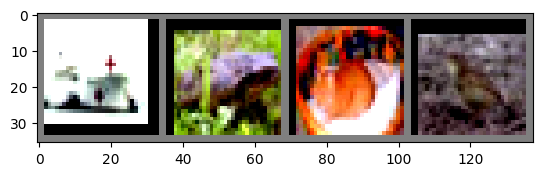

Labels:  ship  frog  cat   bird 


In [17]:
# mostra as primeiras 4 imagens do lote
print("Amostra de imagens de treino\n")
imshow(torchvision.utils.make_grid(images[:4]))

# imprime os labels correspondentes
print("Labels: ", ' '.join(f"{classes[labels[j]]:5s}" for j in range(4)))

## Construção do Modelo de IA — Rede Neural Convolucional (CNN)

A célula abaixo define a arquitetura de uma CNN organizada em dois blocos convolucionais seguidos de um classificador.

__init__(self) — A planta da rede:
Declara todas as camadas que serão usadas:

- Bloco 1 (conv1, conv2) — extrai características iniciais da imagem (bordas, texturas simples). Cada convolução é seguida de BatchNorm2d, que normaliza as ativações e estabiliza o treinamento.

- Bloco 2 (conv3, conv4) — extrai características mais abstratas e complexas com mais filtros (128).

- self.pool — camada de MaxPooling que reduz o tamanho espacial da imagem pela metade a cada aplicação: 32x32 → 16x16 → 8x8. Isso torna o modelo mais eficiente e foca nas características mais relevantes.

- self.dropout — desativa aleatoriamente 50% dos neurônios durante o treino para evitar overfitting.

- self.fc1 e self.fc2 — camadas totalmente conectadas (classificador). A primeira recebe as features achatadas (128 * 8 * 8 = 8192) e a segunda produz 10 saídas, uma para cada classe do CIFAR-10.

forward(self, x) — A linha de montagem:

Define o fluxo exato dos dados pela rede:

1. Imagem 32x32 entra → Conv1 + BN + ReLU → Conv2 + BN + ReLU + Pool → 16x16
2. → Conv3 + BN + ReLU → Conv4 + BN + ReLU + Pool → 8x8
3. → Flatten (achatamento para vetor de 8192 valores)
4. → Dropout + FC1 + ReLU → FC2 → 10 saídas (uma por classe)

In [18]:
# classe para arquitetura do modelo

class ConvNet(nn.Module):


  # Método construtor
  def __init__(self):

    # inicializa o construtor da classe mãe
    super(ConvNet, self).__init__()

    # Bloco 1: 3 -> 32 filtros
    self.conv1 = nn.Conv2d(3, 32, 3, padding = 1)
    self.bn1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32, 64, 3, padding = 1)
    self.bn2 = nn.BatchNorm2d(64)
    self.pool = nn.MaxPool2d(2, 2)

    # Bloco 2: 64 -> 128 filtros
    self.conv3 = nn.Conv2d(64, 128, 3, padding = 1)
    self.bn3 = nn.BatchNorm2d(128)
    self.conv4 = nn.Conv2d(128, 128, 3, padding = 1)
    self.bn4 = nn.BatchNorm2d(128)

    # Classificador
    self.dropout = nn.Dropout(0.5)
    self.fc1 = nn.Linear(128 * 8 * 8, 512)
    self.fc2 = nn.Linear(512, 10)


  # Método forward
  def forward(self, x):

      x = F.relu(self.bn1(self.conv1(x)))
      x = self.pool(F.relu(self.bn2(self.conv2(x))))    # 32x32 -> 16x16
      x = F.relu(self.bn3(self.conv3(x)))
      x = self.pool(F.relu(self.bn4(self.conv4(x))))    # 16x16 -> 8x8
      x = torch.flatten(x, 1)
      x = self.dropout(F.relu(self.fc1(x)))
      x = self.fc2(x)

      return x

A função de ativação ReLU (Rectified Linear Unit) introduz não-linearidade na rede neural, permitindo que o modelo aprenda relações complexas entre os dados.
Sua regra é simples:

ReLU(x) = x, se x > 0   |   0, caso contrário

Ou seja, valores negativos são zerados e apenas os positivos passam adiante. Isso traz três vantagens principais:

- Evita o desaparecimento do gradiente — sem ReLU, os gradientes ficam tão pequenos ao passar por muitas camadas que os pesos param de ser atualizados e a rede para de aprender

- Acelera o treinamento — é uma operação simples e computacionalmente eficiente

- Favorece esparsidade — muitos neurônios ficam com saída zero, tornando a rede mais seletiva e leve

In [19]:
modelo_dsa = ConvNet().to("cpu")

In [20]:
# sumário do modelo
summary(modelo_dsa, (3, 32, 32), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
            Conv2d-3           [-1, 64, 32, 32]          18,496
       BatchNorm2d-4           [-1, 64, 32, 32]             128
         MaxPool2d-5           [-1, 64, 16, 16]               0
            Conv2d-6          [-1, 128, 16, 16]          73,856
       BatchNorm2d-7          [-1, 128, 16, 16]             256
            Conv2d-8          [-1, 128, 16, 16]         147,584
       BatchNorm2d-9          [-1, 128, 16, 16]             256
        MaxPool2d-10            [-1, 128, 8, 8]               0
           Linear-11                  [-1, 512]       4,194,816
          Dropout-12                  [-1, 512]               0
           Linear-13                   [-1, 10]           5,130
Total params: 4,441,482
Trainable param

In [21]:
# instanciando o modelo e movendo para a GPU
modelo = ConvNet().to(device)

In [22]:
print(device)

cuda


## Definindo a Função de Perda e o Otimizador

Função de Perda — CrossEntropyLoss

A função de perda atua como uma "régua" que mede o quão distante as previsões do modelo estão das respostas corretas. CrossEntropyLoss é a escolha padrão para problemas de classificação com múltiplas classes (como as 10 classes do CIFAR-10). Durante o treinamento, ela calcula um único número — a "perda" — que representa o tamanho do erro. O objetivo do treinamento é minimizar esse número ao longo das épocas.

Otimizador — Adam

Se a função de perda mede o erro, o otimizador é quem o corrige. Após cada lote, ele "olha" para o gradiente calculado pelo loss.backward() e ajusta os pesos do modelo para reduzir o erro no próximo passo.
Adam é um dos otimizadores mais populares porque é adaptativo — ele ajusta automaticamente a taxa de aprendizado para cada parâmetro ao longo do treinamento, funcionando bem na maioria dos casos sem exigir muita configuração manual.

Scheduler — ReduceLROnPlateau

Monitora a acurácia de validação a cada época. Quando ela para de melhorar, o scheduler reduz automaticamente a taxa de aprendizado pela metade (factor=0.5), ajudando o modelo a convergir com mais precisão nas fases finais do treinamento.

In [23]:
# Define a função de perda
# O modelo vai buscar os parâmetros que reduzem o erro geral das previsões

criterion = nn.CrossEntropyLoss()

In [24]:
# Otimizador Adam

optimizer = optim.Adam(modelo.parameters(), lr=learning_rate)

# Scheduler - reduz o LR automaticamente quando a acurácia para de melhorar
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 mode='max',
                                                 factor=0.5)

## Treinamento do Modelo

A célula abaixo é o "coração" do processo de treinamento e validação do modelo de IA. De forma resumida, ele faz o seguinte:
Loop Principal de Épocas (for epoch in range(num_epochs)): é o loop externo que faz o modelo "estudar" o conjunto de dados de treinamento inteiro 50 vezes (definido por num_epochs = 50).
Dentro de cada época, existem duas fases:

1. Fase de Treinamento — modelo.train()

Nesta fase, o modelo aprende com os dados:

- for i, (images, labels) in enumerate(loader_treino) — percorre os dados de treino em lotes de 64 imagens por vez

- images.to(device) — move as imagens e os rótulos para o dispositivo correto (GPU ou CPU)

- outputs = modelo(images) — (Forward) o modelo faz as previsões para o lote atual

- loss = criterion(outputs, labels) — calcula o erro comparando as previsões com os rótulos corretos

- optimizer.zero_grad() — limpa os gradientes acumulados da iteração anterior (obrigatório antes do backward)

- loss.backward() — (Backward) calcula como cada peso do modelo contribuiu para o erro, propagando o gradiente de trás para frente

- optimizer.step() — usa o otimizador Adam para ajustar os pesos do modelo e reduzir o erro

- running_loss += loss.item() — acumula a perda para calcular a média ao final da época

---
2. Fase de Avaliação — modelo.eval()

Após treinar uma época completa, o modelo "faz uma prova" com dados que nunca viu:

- modelo.eval() — coloca o modelo em modo de avaliação, desativando o Dropout e o BatchNorm no modo de treino

- with torch.no_grad() — desativa o cálculo de gradientes, economizando memória e acelerando a inferência

- for val_images, val_labels in loader_teste — percorre todo o conjunto de teste

- val_outputs = modelo(val_images) — faz as previsões sobre os dados de teste

- _, predicted = torch.max(val_outputs.data, 1) — extrai a classe com maior pontuação para cada imagem

- n_correct += (predicted == val_labels).sum().item() — conta o total de acertos comparando previsão com rótulo real

---
3. Relatório de Progresso

Ao final de cada época, o script imprime um resumo com:

- avg_loss — erro médio da fase de treino (running_loss / n_total_steps)

- acc — acurácia no conjunto de teste (n_correct / n_samples * 100)

- scheduler.step(acc) — o scheduler monitora a acurácia e reduz o learning rate automaticamente se ela parar de melhorar

Exemplo de saída: Epoch [10/50] -- Erro em treino: 0.8432 -- Acurácia em teste: 72.15%


In [25]:
%%time

print("\nIniciando o treinamento...\n")

# Calcula o total de passos por epochs
n_total_steps = len(loader_treino)

# Loop principal do treinamento
for epoch in range(num_epochs):

  # coloca o modelo em modo de treinamento
  modelo.train()

  # inicializa o acumulador de perda
  running_loss = 0.0

  # itera sobre os batches do conjunto de treino
  for i, (images, labels) in enumerate(loader_treino):

    # move os tensores (imagens e rótulos) para o dispositivo (cpu ou gpu) próximo do modelo
    images = images.to(device)
    labels = labels.to(device)

    # forward (previsão do modelo)
    outputs = modelo(images)

    # calcula o erro do modelo
    loss = criterion(outputs, labels)

    # zera os gradientes acumulados de iterações anteriores
    optimizer.zero_grad()

    # calcula os gradientes via backpropagation
    loss.backward()

    # atualiza os pesos do modelo
    optimizer.step()

    # soma o valor da perda para calculo médio posterior
    running_loss += loss.item()


  # Após cada epoch, avalia o modelo no conjunto de teste
  # coloca o modelo em modo de avaliação
  modelo.eval()

  # Desativa o calculo de gradientes para economizar memória
  with torch.no_grad():

    n_correct = 0   # num de acertos
    n_samples = 0   # num de amostras

    # loop sobre o conjunto de teste
    for val_images, val_labels in loader_teste:

      # move imagens e rótulos para o dispositivo
      val_images = val_images.to(device)
      val_labels = val_labels.to(device)

      # faz a inferência no conjunto de teste
      val_outputs = modelo(val_images)

      # torch.max retorna (valor, índice) → pegamos o índice da classe prevista
      _, predicted = torch.max(val_outputs.data, 1)

      # incrementa o total de amostras
      n_samples += val_labels.size(0)

      # incrementa o número de acertos
      n_correct += (predicted == val_labels).sum().item()


  # Calcula a acurácia e a perda média da epoch
  acc = 100.0 * n_correct / n_samples
  avg_loss = running_loss / n_total_steps

  # Exibe métricas de desemepenho
  print(f"Epoch [{epoch+1}/{num_epochs}] -- Erro em treino: {avg_loss:.4f} -- Acurácia em teste: {acc:.2f}%")

  # Atualiza o scheduler com a acurácia atual
  scheduler.step(acc)

# Exibe mensagem no final do treinamento
print("\nTreinamento Finalizado!\n")


Iniciando o treinamento...

Epoch [1/50] -- Erro em treino: 1.7957 -- Acurácia em teste: 48.08%
Epoch [2/50] -- Erro em treino: 1.4412 -- Acurácia em teste: 61.37%
Epoch [3/50] -- Erro em treino: 1.2650 -- Acurácia em teste: 63.29%
Epoch [4/50] -- Erro em treino: 1.1392 -- Acurácia em teste: 68.23%
Epoch [5/50] -- Erro em treino: 1.0577 -- Acurácia em teste: 72.36%
Epoch [6/50] -- Erro em treino: 0.9947 -- Acurácia em teste: 73.02%
Epoch [7/50] -- Erro em treino: 0.9432 -- Acurácia em teste: 73.47%
Epoch [8/50] -- Erro em treino: 0.8922 -- Acurácia em teste: 76.34%
Epoch [9/50] -- Erro em treino: 0.8566 -- Acurácia em teste: 76.73%
Epoch [10/50] -- Erro em treino: 0.8160 -- Acurácia em teste: 77.41%
Epoch [11/50] -- Erro em treino: 0.7826 -- Acurácia em teste: 79.00%
Epoch [12/50] -- Erro em treino: 0.7505 -- Acurácia em teste: 77.99%
Epoch [13/50] -- Erro em treino: 0.7167 -- Acurácia em teste: 80.68%
Epoch [14/50] -- Erro em treino: 0.6973 -- Acurácia em teste: 80.92%
Epoch [15/50] 

## Avaliação do Modelo

Este bloco executa a avaliação final do modelo usando o conjunto de teste — dados que ele nunca viu durante o treinamento.

modelo.eval() coloca a rede em modo de avaliação, desativando camadas como o Dropout (que só atua no treino). with torch.no_grad() desativa o cálculo de gradientes, pois não há mais aprendizado nessa etapa — isso economiza memória e acelera a inferência.

O loop percorre todos os lotes do loader_teste. Para cada lote, o modelo faz previsões (outputs), e torch.max extrai a classe com maior pontuação (predicted). Os acertos são acumulados para calcular a acurácia geral.

Simultaneamente, o loop interno analisa cada imagem individualmente para calcular a acurácia por classe, preenchendo n_class_correct e n_class_samples. Ao final, são exibidos:

- A acurácia geral do modelo (ex: Acurácia geral: 85.00%)

- A acurácia individual de cada uma das 10 classes do CIFAR-10 (ex: Acurácia da classe car: 91.20%)

Essa análise por classe é essencial para identificar onde o modelo está errando mais — classes visualmente parecidas (como cat e dog) tendem a ter acurácias menores.

In [26]:
modelo.eval()

# Desativa o calculo de gradientes pois não é necessário
with torch.no_grad():

  # inicializa o contador de acertos totais
  n_correct = 0

  # incializa o contador de amostras
  n_samples = 0

  # lista para contar acertos por classe
  n_class_correct = [0 for _ in range(10)]

  # lista para contar total de amostras por classes
  n_class_samples = [0 for _ in range(10)]


  # Loop sobre o conjunto de teste
  for images, labels in loader_teste:

    # move imagens para o dispositivo
    images = images.to(device)

    # move rótulos para o mesmo dispositivo
    labels = labels.to(device)

    # faz a inferência com o modelo
    outputs = modelo(images)

    # obtém as classes com maior probabilidade
    _, predicted = torch.max(outputs, 1)

    # incrementa o número total de amostras
    n_samples += labels.size(0)

    # incrementa o número total de acertos
    n_correct += (predicted == labels).sum().item()


    # Calcular a acurácia por classe
    for i in range(len(labels)):

        # Obtém o rótulo verdadeiro
        label = labels[i]

        # Obtém o rótulo previsto
        pred = predicted[i]

        # Incrementa o contador da classe se estiver certo
        if (label == pred):
            n_class_correct[label] += 1

        # Incremento total da classe
        n_class_samples[label] += 1


  # Calcula a acurácia geral do modelo
  acc_geral = 100.0 * n_correct / n_samples

  # Exibindo resultado
  print(f"Acurácia geral do modelo na base de teste: {acc_geral:.2f}%")
  print("-" * 30)
  print("\n")


  # Loop para calcular e exibir a acurácia de cada classe
  for i in range(10):

    # se houver amostras para as classes
    if n_class_samples[i] > 0:

        # calcula a acurácia da classe
        acc_classe = 100.0 * n_class_correct[i] / n_class_samples[i]

        # exibe acurácia da classe
        print(f"Acurácia da classe {classes[i]}: {acc_classe:.2f}%")

    # Caso não existam amostras da classe
    else:
        print(f"Acurácia da classe {classes[i]}: N/A (sem amostras)")

Acurácia geral do modelo na base de teste: 87.91%
------------------------------


Acurácia da classe plane: 93.40%
Acurácia da classe car: 93.60%
Acurácia da classe bird: 80.30%
Acurácia da classe cat: 75.20%
Acurácia da classe deer: 92.30%
Acurácia da classe dog: 82.30%
Acurácia da classe frog: 92.90%
Acurácia da classe horse: 90.80%
Acurácia da classe ship: 89.20%
Acurácia da classe truck: 89.10%


In [27]:
# Salvando modelo em disco
PATH = './modelo.pth'
torch.save(modelo.state_dict(), PATH)
print(f"Modelo salvo em {PATH}")

Modelo salvo em ./modelo.pth


## Uso do Modelo

In [28]:
# Cria umaa nova instância do modelo
model_carregado = ConvNet().to(device)

In [29]:
model_carregado.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [30]:
# colocar o modelo em modo de avaliação
model_carregado.eval()

ConvNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

In [31]:
# Definir as transformações para novos dados
# sempre deve ser as mesmas que utilizamo no treino

inference_transform = transforms.Compose([
    transforms.Resize((32, 32)),          # garante que as imagens vão ter o mesmo tamanho
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [32]:
# Função para prever as novas imagens

def classifica_imagem(image_path, model):

    """
    Carrega uma imagem de um caminho local, aplica as transformações
    e faz a predição usando o modelo treinado.
    """

    try:
        # Carrega a imagem
        img_pil = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Erro ao carregar imagem local {image_path}: {e}")
        return


    # Aplicar transformações
    img_tensor = inference_transform(img_pil)

    # Adcionamos uma dimensão extra
    img_tensor = img_tensor.unsqueeze(0).to(device)


    # Fazer a predição
    model.eval()  # garantir que está em modo de avaliação
    with torch.no_grad():

        outputs = model(img_tensor)

        probabilities = F.softmax(outputs, dim=1)

        # Obter classe com maior probabilidade
        _, predicted_idx = torch.max(outputs, 1)


    classe_predita = classes[predicted_idx.item()]

    confianca = torch.max(probabilities).item() * 100


    # Mostrar a imagem e a predição
    plt.imshow(img_pil)
    plt.title(rf'Classe Prevista Pelo Modelo: $\bf{{{classe_predita}}}$ (Confiança: {confianca:.2f}%)')
    plt.axis("off")
    plt.show()

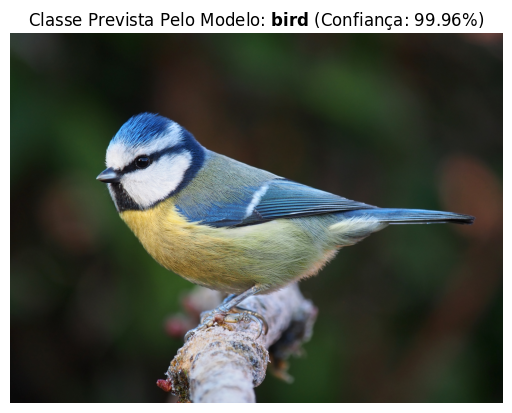

In [34]:
classifica_imagem("imagem1.jpg", model_carregado)

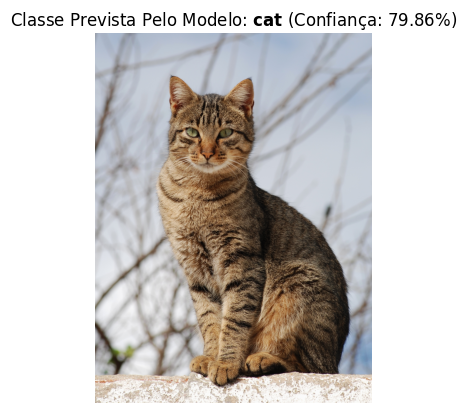

In [35]:
classifica_imagem("imagem2.jpg", model_carregado)

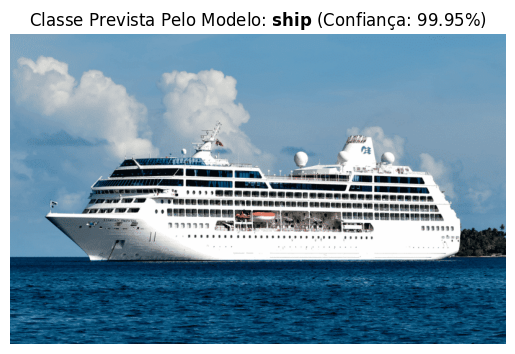

In [36]:
classifica_imagem("imagem3.png", model_carregado)

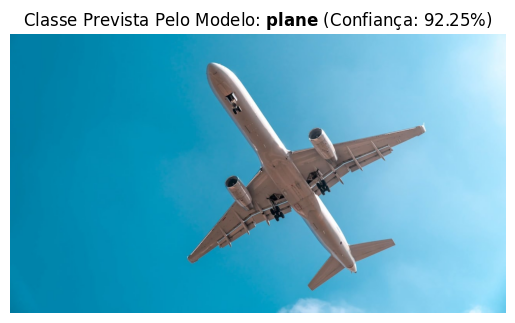

In [37]:
classifica_imagem("imagem4.jpg", model_carregado)

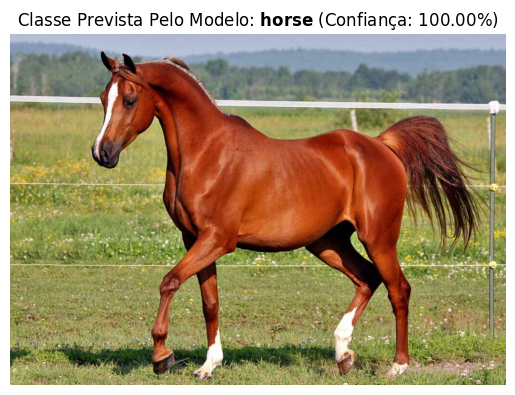

In [38]:
classifica_imagem("imagem5.jpg", model_carregado)